In [ ]:
!pip install prophet --quiet # 설치 진행

In [ ]:
from prophet import Prophet
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [ ]:
df = pd.read_csv("/content/산불발생여부와_일별합계.csv")  # 너 파일 이름 맞게 조정해줘

In [ ]:
df_prophet = df.rename(columns={'date': 'ds', '일별_합계': 'y'})

In [ ]:
df.head()

,date,일별_합계,산불발생여부
0,2016-01-01,0,0
1,2016-01-02,0,0
2,2016-01-03,1,1
3,2016-01-04,0,0
4,2016-01-05,1,1


In [ ]:
df_prophet.head()

,ds,y,산불발생여부
0,2016-01-01,0,0
1,2016-01-02,0,0
2,2016-01-03,1,1
3,2016-01-04,0,0
4,2016-01-05,1,1


## **2025년에 총 몇 건 일어날지(년 단위)**

---


검증을 위해 2016부터 2023년까지 범위로 해서 2024년 테스트

In [ ]:
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
train = df_prophet[df_prophet['ds'] < '2024-01-01']
test = df_prophet[df_prophet['ds'] >= '2024-01-01']

In [ ]:
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/b659wm12.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/y4gw8aqz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=96059', 'data', 'file=/tmp/tmp6b26gedp/b659wm12.json', 'init=/tmp/tmp6b26gedp/y4gw8aqz.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_model175zwj44/prophet_model-20250514012601.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:01 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:01 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
model = Prophet(yearly_seasonality=True, daily_seasonality=False)
model.fit(train)


DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/g7fojmpf.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/l6s0_xvj.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=56702', 'data', 'file=/tmp/tmp6b26gedp/g7fojmpf.json', 'init=/tmp/tmp6b26gedp/l6s0_xvj.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_modeldyw6ckwo/prophet_model-20250514012602.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:02 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:02 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

In [ ]:
pred2 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred2['y'], pred2['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred2['y'], pred2['yhat'])
r2 = r2_score(pred2['y'], pred2['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.7191
MSE  : 2.9551
MAE  : 1.1326
R²   : -0.2405




---



**튜닝 진행(1)**

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

In [ ]:
model = Prophet(
    yearly_seasonality=True,                   # 연간 게절성
    daily_seasonality=False,                   # 일간 패턴
    seasonality_mode='multiplicative',         # 계절성 곱셈 (additive or multiplicative)
    changepoint_prior_scale=0.2,               # 추세 변화 민감도 증가 (기본 0.05)
    seasonality_prior_scale=15.0               # 계절성 민감도 (기본 10.0)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/94ri32ph.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/b_4pu4zs.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=77727', 'data', 'file=/tmp/tmp6b26gedp/94ri32ph.json', 'init=/tmp/tmp6b26gedp/b_4pu4zs.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_modeljtm9lxhz/prophet_model-20250514012603.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:03 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:03 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

pred2 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred2['y'], pred2['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred2['y'], pred2['yhat'])
r2 = r2_score(pred2['y'], pred2['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.7808
MSE  : 3.1713
MAE  : 1.1833
R²   : -0.3313




---



**튜닝 진행(2)**

In [ ]:
model = Prophet(
    yearly_seasonality=True,                   # 연간 게절성
    daily_seasonality=False,                   # 일간 패턴
    seasonality_mode='additive',               # 계절성 곱셈 (additive or multiplicative)
    changepoint_prior_scale=0.05,              # 추세 변화 민감도 증가 (기본 0.05)
    seasonality_prior_scale=7.0                # 계절성 민감도 (기본 10.0)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/1iokm37u.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/3fw3oiy7.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=12161', 'data', 'file=/tmp/tmp6b26gedp/1iokm37u.json', 'init=/tmp/tmp6b26gedp/3fw3oiy7.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_modeleikbrinj/prophet_model-20250514012604.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:04 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:05 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

pred3 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred3['y'], pred3['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred3['y'], pred3['yhat'])
r2 = r2_score(pred3['y'], pred3['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.7263
MSE  : 2.9803
MAE  : 1.1352
R²   : -0.2511




---



**튜닝 진행(3)**

In [ ]:
model = Prophet(
    yearly_seasonality=True,                   # 연간 게절성
    daily_seasonality=False,                   # 일간 패턴
    seasonality_mode='additive',               # 계절성 곱셈 (additive or multiplicative)
    changepoint_prior_scale=0.03,              # 추세 변화 민감도 증가 (기본 0.05)
    seasonality_prior_scale=5.0                # 계절성 민감도 (기본 10.0)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/yjkuqkc5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/73_xbhge.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=84984', 'data', 'file=/tmp/tmp6b26gedp/yjkuqkc5.json', 'init=/tmp/tmp6b26gedp/73_xbhge.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_modelltdet6ss/prophet_model-20250514012605.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:05 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:06 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

pred4 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred4['y'], pred4['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred4['y'], pred4['yhat'])
r2 = r2_score(pred4['y'], pred4['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.7841
MSE  : 3.1830
MAE  : 1.1947
R²   : -0.3362




---



**튜닝 진행(4)**

In [ ]:
model = Prophet(
    yearly_seasonality=True,                   # 연간 게절성
    daily_seasonality=False,                   # 일간 패턴
    seasonality_mode='additive',               # 계절성 곱셈 (additive or multiplicative)
    changepoint_prior_scale=0.05,              # 추세 변화 민감도 증가 (기본 0.05)
    seasonality_prior_scale=18.0                # 계절성 민감도 (기본 10.0)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/hvvookl5.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/da1ds2mv.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=4033', 'data', 'file=/tmp/tmp6b26gedp/hvvookl5.json', 'init=/tmp/tmp6b26gedp/da1ds2mv.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_modelb9393kd2/prophet_model-20250514012607.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:07 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:07 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

pred4 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred4['y'], pred4['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred4['y'], pred4['yhat'])
r2 = r2_score(pred4['y'], pred4['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.7242
MSE  : 2.9729
MAE  : 1.1347
R²   : -0.2480




---



**튜닝 진행(5)**

In [ ]:
model = Prophet(
    yearly_seasonality=True,                   # 연간 게절성
    daily_seasonality=False,                   # 일간 패턴
    seasonality_mode='additive',               # 계절성 곱셈 (additive or multiplicative)
    changepoint_prior_scale=0.07,              # 추세 변화 민감도 증가 (기본 0.05)
    seasonality_prior_scale=20.0                # 계절성 민감도 (기본 10.0)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/jtntibqk.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/ik1jpto5.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=84388', 'data', 'file=/tmp/tmp6b26gedp/jtntibqk.json', 'init=/tmp/tmp6b26gedp/ik1jpto5.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_modelo2p5s1f2/prophet_model-20250514012608.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:08 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:08 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

pred5 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred5['y'], pred5['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred5['y'], pred5['yhat'])
r2 = r2_score(pred5['y'], pred5['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.6920
MSE  : 2.8629
MAE  : 1.1376
R²   : -0.2018


추세 변화 민감도와 게절성 민감도를 높였을 때의 결과가 확실히 잘 나오는 느낌이 있는데 과적합 과 같은 우려가 생길 것 같아서 확인 필요

	•	changepoint_prior_scale: 0.01 ~ 0.2
	•	seasonality_prior_scale: 5 ~ 20 <br>
    기본적인.. 추천 적인 가이드인데 이 기준에 맞춰서 진행하려고 했지만!!

    30이상부터 과적합 적인 요소들을 판단한다고 하길래 그 이하까지 해보고 일단 판단 예정



---



**튜닝 진행(6)**

In [ ]:
model = Prophet(
    yearly_seasonality=True,                   # 연간 게절성
    daily_seasonality=False,                   # 일간 패턴
    seasonality_mode='additive',               # 계절성 곱셈 (additive or multiplicative)
    changepoint_prior_scale=1.0,              # 추세 변화 민감도 증가 (기본 0.05)
    seasonality_prior_scale=15.0                # 계절성 민감도 (기본 10.0)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/3cko2v00.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/boa76yod.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=9550', 'data', 'file=/tmp/tmp6b26gedp/3cko2v00.json', 'init=/tmp/tmp6b26gedp/boa76yod.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_model_c9mdkm4/prophet_model-20250514012611.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:11 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:15 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

pred6 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred6['y'], pred6['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred6['y'], pred6['yhat'])
r2 = r2_score(pred6['y'], pred6['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.7825
MSE  : 3.1775
MAE  : 1.2977
R²   : -0.3339


=> 추세 변화 민감도 보다는 계절성 민감도가 조금 더 중요해보이는 걸 발견



---



**튜닝 진행(7)**

In [ ]:
model = Prophet(
    yearly_seasonality=True,                   # 연간 게절성
    daily_seasonality=False,                   # 일간 패턴
    seasonality_mode='additive',               # 계절성 곱셈 (additive or multiplicative)
    changepoint_prior_scale=0.05,              # 추세 변화 민감도 증가 (기본 0.05)
    seasonality_prior_scale=20.0                # 계절성 민감도 (기본 10.0)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/qpjddhg7.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/jck4198a.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87770', 'data', 'file=/tmp/tmp6b26gedp/qpjddhg7.json', 'init=/tmp/tmp6b26gedp/jck4198a.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_model5ltek5u_/prophet_model-20250514012617.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:17 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:17 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

pred7 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred7['y'], pred7['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred7['y'], pred7['yhat'])
r2 = r2_score(pred7['y'], pred7['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.7271
MSE  : 2.9829
MAE  : 1.1357
R²   : -0.2522




---



**튜닝진행(8)**

In [ ]:
model = Prophet(
    yearly_seasonality=True,                   # 연간 게절성
    daily_seasonality=False,                   # 일간 패턴
    seasonality_mode='additive',               # 계절성 곱셈 (additive or multiplicative)
    changepoint_prior_scale=0.07,              # 추세 변화 민감도 증가 (기본 0.05)
    seasonality_prior_scale=25.0                # 계절성 민감도 (기본 10.0)
)
model.fit(train)

DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/411q7bui.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/0ar911y_.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=8540', 'data', 'file=/tmp/tmp6b26gedp/411q7bui.json', 'init=/tmp/tmp6b26gedp/0ar911y_.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_modelqnh15fvg/prophet_model-20250514012619.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:19 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:20 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

pred8 = forecast[['ds', 'yhat']].merge(test[['ds', 'y']], on='ds', how='inner')

In [ ]:
mse = mean_squared_error(pred8['y'], pred8['yhat'])
rmse = np.sqrt(mse)
mae = mean_absolute_error(pred8['y'], pred8['yhat'])
r2 = r2_score(pred8['y'], pred8['yhat'])

print(f"RMSE : {rmse:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

RMSE : 1.6941
MSE  : 2.8698
MAE  : 1.1359
R²   : -0.2047




---



**튜닝 잘 나온 값으로 1차 시각화(2024년 예측해서 비교해본 거)**

In [ ]:
from prophet.plot import plot_plotly
import matplotlib.pyplot as plt

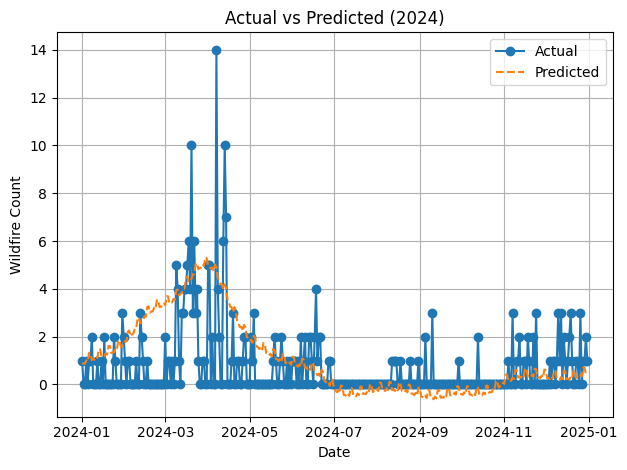

In [ ]:
plt.plot(pred5['ds'], pred5['y'], label='Actual', marker='o')
plt.plot(pred5['ds'], pred5['yhat'], label='Predicted', linestyle='--')
plt.title("Actual vs Predicted (2024)")
plt.xlabel("Date")
plt.ylabel("Wildfire Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **2025년 예측 진행!!**

In [ ]:
best_params = {
    'changepoint_prior_scale': 0.07,
    'seasonality_prior_scale': 20.0,
    'seasonality_mode': 'additive'
}

df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])
train_all = df_prophet[df_prophet['ds'] < '2025-01-01']

model = Prophet(
    yearly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=best_params['changepoint_prior_scale'],
    seasonality_prior_scale=best_params['seasonality_prior_scale'],
    seasonality_mode=best_params['seasonality_mode']
)

model.fit(train_all)


DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/luv52r7q.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp6b26gedp/thrqke7n.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=19495', 'data', 'file=/tmp/tmp6b26gedp/luv52r7q.json', 'init=/tmp/tmp6b26gedp/thrqke7n.json', 'output', 'file=/tmp/tmp6b26gedp/prophet_model3jrbkccp/prophet_model-20250514012622.csv', 'method=optimize', 'algorithm=lbfgs', 'iter=10000']
01:26:22 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
01:26:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [ ]:
# 365일 예측
future = model.make_future_dataframe(periods=365)
forecast = model.predict(future)

# 2025년 예측만 추출
forecast_2025 = forecast[forecast['ds'].dt.year == 2025]

In [ ]:
total_2025 = forecast_2025['yhat'].sum()
print(f"2025년 총 산불 발생 건수 (예측): {total_2025:.2f}건")

2025년 총 산불 발생 건수 (예측): 144.93건


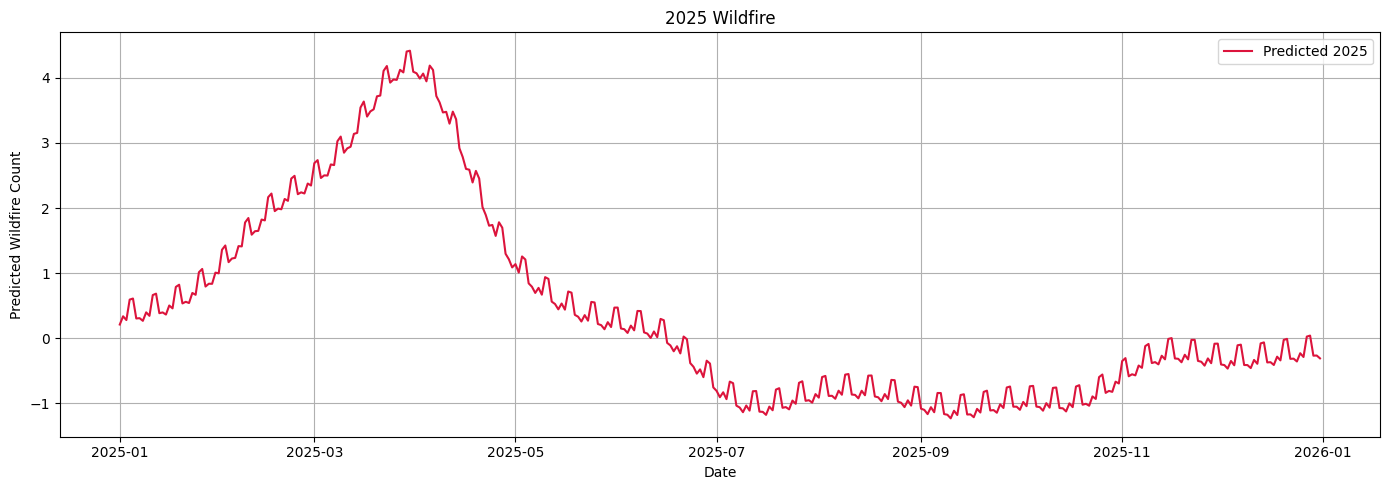

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='Predicted 2025', color='crimson')
plt.title("2025 Wildfire")
plt.xlabel("Date")
plt.ylabel("Predicted Wildfire Count")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

특이일자 확인 (예: 5건 이상 예측)

In [ ]:
forecast_2025[forecast_2025['yhat'] > 5].sort_values(by='yhat', ascending=False).head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat


In [ ]:
# 예측 3건 초과로 테스트
high_days = forecast_2025[forecast_2025['yhat'] > 3].sort_values(by='yhat', ascending=False)
print(f"3건 초과 날짜 수: {len(high_days)}")

3건 초과 날짜 수: 34


In [ ]:
# 실제 출력 루프 (값 있으면 실행됨)
for i, row in high_days.head(5).iterrows():
    ds = row['ds'].date()
    yhat = row['yhat']
    trend = row['trend']
    yearly = row['yearly']
    weekly = row['weekly']
    lower = row['yhat_lower']
    upper = row['yhat_upper']

    print(f"{ds}: 예측 {yhat:.2f}건")
    print(f"추세: {trend:.2f} / yearly: {yearly:.2f} / weekly: {weekly:.2f}")
    print(f"예측 구간: {lower:.2f} ~ {upper:.2f}")
    print("-" * 50)

2025-03-30: 예측 4.42건
추세: 0.53 / yearly: 3.66 / weekly: 0.23
예측 구간: 1.46 ~ 7.62
--------------------------------------------------
2025-03-29: 예측 4.40건
추세: 0.53 / yearly: 3.66 / weekly: 0.22
예측 구간: 1.52 ~ 7.26
--------------------------------------------------
2025-04-05: 예측 4.19건
추세: 0.52 / yearly: 3.45 / weekly: 0.22
예측 구간: 1.20 ~ 7.08
--------------------------------------------------
2025-03-23: 예측 4.18건
추세: 0.54 / yearly: 3.42 / weekly: 0.23
예측 구간: 1.33 ~ 7.24
--------------------------------------------------
2025-03-27: 예측 4.12건
추세: 0.53 / yearly: 3.61 / weekly: -0.02
예측 구간: 1.35 ~ 7.14
--------------------------------------------------


# **월별 출력**

In [ ]:
# 'ds' 컬럼을 datetime 형식으로 변환
forecast_2025['ds'] = pd.to_datetime(forecast_2025['ds'])

# '연-월'만 추출
forecast_2025['year_month'] = forecast_2025['ds'].dt.to_period('M')

# 월별 예측값 합계 구하기
monthly_sum = forecast_2025.groupby('year_month')['yhat'].sum().reset_index()

# Period 타입을 datetime으로 변환 (그래프용)
monthly_sum['year_month'] = monthly_sum['year_month'].dt.to_timestamp()

# 확인
print(monthly_sum)

   year_month        yhat
0  2025-01-01   18.298805
1  2025-02-01   52.304357
2  2025-03-01  105.644921
3  2025-04-01   83.147186
4  2025-05-01   18.320329
5  2025-06-01   -1.762701
6  2025-07-01  -29.223737
7  2025-08-01  -25.354067
8  2025-09-01  -31.220919
9  2025-10-01  -28.011664
10 2025-11-01   -8.765247
11 2025-12-01   -8.447123


<ipython-input-50-ba482041c516>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast_2025['ds'] = pd.to_datetime(forecast_2025['ds'])
<ipython-input-50-ba482041c516>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  forecast_2025['year_month'] = forecast_2025['ds'].dt.to_period('M')


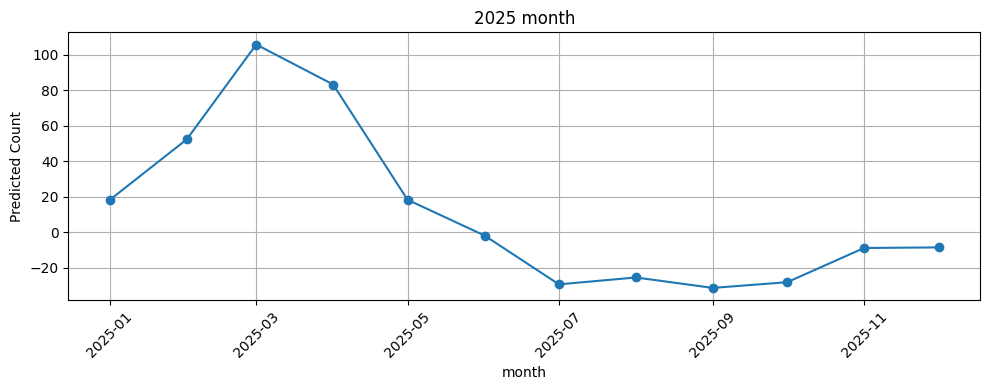

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(monthly_sum['year_month'], monthly_sum['yhat'], marker='o')
plt.title('2025 month')
plt.xlabel('month')
plt.ylabel('Predicted Count')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

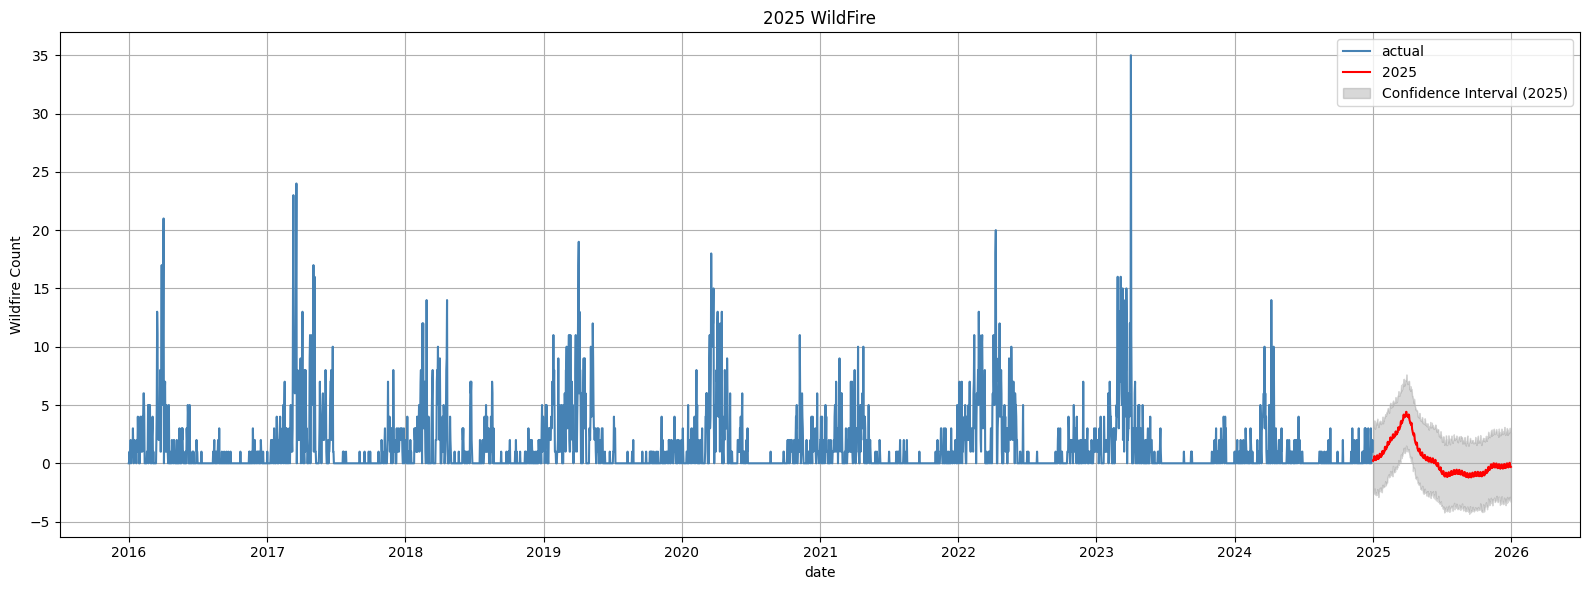

In [ ]:
import matplotlib.pyplot as plt

# 기존 실제값 (2016~2024)
historical = df_prophet[df_prophet['ds'] < '2025-01-01']

# 2025년 예측값만
forecast_2025 = forecast[(forecast['ds'] >= '2025-01-01') & (forecast['ds'] <= '2025-12-31')]

# 시각화
plt.figure(figsize=(16, 6))

# 실제값 (2016~2024)
plt.plot(historical['ds'], historical['y'], label='actual', color='steelblue')

# 예측값 (2025)
plt.plot(forecast_2025['ds'], forecast_2025['yhat'], label='2025', color='red')

# 신뢰 구간 (회색 그림자)
plt.fill_between(
    forecast_2025['ds'],
    forecast_2025['yhat_lower'],
    forecast_2025['yhat_upper'],
    color='gray',
    alpha=0.3,
    label='Confidence Interval (2025)'
)

plt.title('2025 WildFire')
plt.xlabel('date')
plt.ylabel('Wildfire Count')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()